# Phân tích Câu hỏi — “Vùng trũng giá trị” & Khu vực “thổi giá”



## 1. Câu hỏi nghiên cứu
**Câu hỏi:** "Làm thế nào để xác định các khu vực (Quận/Phường) là 'vùng trũng giá trị' - nơi người thuê nhận được lợi ích tối đa (diện tích, tiện nghi, an ninh, vị trí) với mức chi phí thấp nhất, và đâu là những khu vực đang bị 'thổi giá' (overpriced)?"

**Tính xác thực:** Câu hỏi này có thể trả lời trực tiếp bằng dữ liệu thông qua việc xây dựng một chỉ số tổng hợp (**Cost Efficiency Index – CEI**) từ các biến định lượng sẵn có như `price`, `area`, `amenity_score`, `security_score`, và `location_score`.


## 2. Động cơ & Lợi ích
* **Vì sao đáng nghiên cứu?** Nếu chỉ nhìn vào **giá thuê thấp**, người thuê dễ “mua rẻ nhưng nhận kém” (phòng nhỏ, thiếu tiện nghi/an ninh, vị trí kém). Phân tích này chuyển trọng tâm từ **“rẻ”** sang **“đáng tiền”**.
* **Lợi ích & Insight:** Xác định “**viên ngọc ẩn**” — khu vực có **hiệu suất lợi ích/chi phí** cao; đồng thời chỉ ra khu vực **bị thổi giá** (chi phí cao nhưng lợi ích tương đối thấp).
* **Đối tượng quan tâm:**
  * **Sinh viên & Người lao động:** Tối ưu chỗ ở theo ngân sách.
  * **Chủ nhà/nhà đầu tư:** Hiểu “mặt bằng cạnh tranh” theo khu vực để điều chỉnh tiện ích/giá.
* **Hỗ trợ thực tế:** Trả lời được câu hỏi kiểu: "Với 4–5 triệu, tôi nên ưu tiên khu nào để **được diện tích + tiện nghi** tốt nhất?"


### A. Tiền xử lý dữ liệu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH = "../../data/processed/data_clean.csv"
df = pd.read_csv(PATH)

for col in ["price","area","price_per_sqm","amenity_score","location_score","security_score","log_price"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

def normalize_district(x):
    if pd.isna(x): 
        return x
    s = str(x).strip().lower()
    if s.isdigit():
        return f"q{s}"
    return " ".join([w.capitalize() for w in s.split()])

df["district_std"] = df["district"].apply(normalize_district)
df["ward_str"] = df["ward"].astype(str)

df.shape

(28554, 36)

In [3]:
# Missing check (key columns)
key_cols = ["price","area","price_per_sqm","district_std","ward_str","amenity_score","location_score","security_score"]
miss_pct = (df[key_cols].isna().mean()*100).sort_values(ascending=False).round(2)
miss_pct

price             0.0
area              0.0
price_per_sqm     0.0
district_std      0.0
ward_str          0.0
amenity_score     0.0
location_score    0.0
security_score    0.0
dtype: float64

### B. Phân tích

#### B1) Xây dựng chỉ số Cost Efficiency Index (CEI)

**Ý tưởng:**  
- **Benefit** (lợi ích) = tổng hợp từ `area`, `amenity_score`, `security_score`, `location_score` (sau khi chuẩn hoá về [0,1])  
- **Cost** (chi phí) = `price` (chuẩn hoá [0,1])  
- **CEI = Benefit / Cost** (CEI cao → “đáng tiền” hơn, CEI thấp → “overpriced” hơn)

> Đây là chỉ số EDA hỗ trợ so sánh tương đối giữa khu vực, không phải kết luận nhân quả.


In [4]:
# Prepare for CEI
work = df.copy()

for c in ["price","area","amenity_score","security_score","location_score"]:
    work[c] = pd.to_numeric(work[c], errors="coerce")

# Fill missing with medians (robust enough for EDA)
for c in ["price","area","amenity_score","security_score","location_score"]:
    work[c] = work[c].fillna(work[c].median())

# Remove non-positive price/area
work = work[(work["price"]>0) & (work["area"]>0)].copy()

def minmax(s):
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)

work["price_norm"] = minmax(work["price"])
work["area_norm"]  = minmax(work["area"])
work["amen_norm"]  = minmax(work["amenity_score"])
work["sec_norm"]   = minmax(work["security_score"])
work["loc_norm"]   = minmax(work["location_score"])

work["benefit"] = work["area_norm"] + work["amen_norm"] + work["sec_norm"] + work["loc_norm"]
eps = 1e-6
work["CEI"] = work["benefit"] / (work["price_norm"] + eps)

work[["price","area","amenity_score","security_score","location_score","benefit","CEI"]].head()

,price,area,amenity_score,security_score,location_score,benefit,CEI
0,5500000.0,30.0,9,3,0,2.092308,3.719652
1,3500000.0,26.0,3,1,1,1.217436,3.895782
2,4500000.0,15.0,1,0,1,0.510256,1.166298
3,1400000.0,18.0,9,3,1,2.185641,43.711946
4,4500000.0,35.0,7,2,0,1.705128,3.897427


#### B2) Tổng quan theo district: P10–P90, IQR và “loạn giá”

- P10–P90: khoảng giá “thường gặp”  
- IQR/Median: mức độ phân tán tương đối (cao → “loạn giá” hơn)


In [5]:
def q(s, p): 
    return s.quantile(p)

g = work.groupby("district_std")

district_summary = (
    g.agg(
        n=("price","size"),
        price_median=("price","median"),
        price_p10=("price", lambda s: q(s, 0.10)),
        price_p25=("price", lambda s: q(s, 0.25)),
        price_p75=("price", lambda s: q(s, 0.75)),
        price_p90=("price", lambda s: q(s, 0.90)),

        ppsm_median=("price_per_sqm","median"),
        area_median=("area","median"),
        amen_mean=("amenity_score","mean"),
        sec_mean=("security_score","mean"),
        loc_mean=("location_score","mean"),

        cei_median=("CEI","median"),
        cei_mean=("CEI","mean"),
    )
    .reset_index()
)

district_summary["price_IQR"] = district_summary["price_p75"] - district_summary["price_p25"]
district_summary["price_IQR_over_median"] = district_summary["price_IQR"] / district_summary["price_median"]

district_summary = district_summary.sort_values("n", ascending=False)
district_summary.head(12)

,district_std,n,price_median,price_p10,price_p25,price_p75,price_p90,ppsm_median,area_median,amen_mean,sec_mean,loc_mean,cei_median,cei_mean,price_IQR,price_IQR_over_median
1,Bình Thạnh,3786,4800000.0,2600000.0,3800000.0,5700000.0,6500000.0,171428.571429,30.0,3.439514,1.062863,0.617274,2.510709,2305.907286,1900000.0,0.395833
4,Gò Vấp,3397,3500000.0,2100000.0,3000000.0,4250000.0,5000000.0,142307.692308,25.0,3.366205,1.044157,0.599352,3.221704,6874.142625,1250000.0,0.357143
10,Tân Bình,3106,4000000.0,2500000.0,3200000.0,4900000.0,5800000.0,150714.619048,25.0,3.275596,1.018674,0.457502,2.737766,1647.105080,1700000.0,0.425000
9,Thủ Đức,2778,3500000.0,1800000.0,2600000.0,4200000.0,5000000.0,135000.000000,25.0,3.113031,1.188625,0.688625,3.717931,7125.594050,1600000.0,0.457143
11,Tân Phú,2387,3500000.0,2300000.0,3000000.0,4000000.0,4800000.0,133333.333333,26.0,3.239631,1.226225,0.985756,4.201019,4564.945509,1000000.0,0.285714
2,Bình Tân,1799,2900000.0,1800000.0,2400000.0,3400000.0,4000000.0,116666.666667,25.0,2.870484,1.188438,0.682601,4.731599,1661.667567,1000000.0,0.344828
21,q7,1636,4000000.0,2200000.0,3300000.0,5000000.0,5850000.0,157142.857143,25.0,3.239609,0.938875,0.865526,2.890934,4104.374948,1700000.0,0.425000
15,q12,1461,2800000.0,1700000.0,2250000.0,3500000.0,4000000.0,116666.666667,25.0,3.164271,1.178645,0.569473,4.802391,5820.751252,1250000.0,0.446429
8,Phú Nhuận,1314,4800000.0,2800000.0,3700000.0,5700000.0,6500000.0,173913.043478,27.0,3.523592,1.042618,0.280822,2.150355,912.779777,2000000.0,0.416667
13,q10,1113,4500000.0,1900000.0,3000000.0,5500000.0,6300000.0,177777.777778,25.0,3.701707,1.008086,0.675651,2.789726,6248.672606,2500000.0,0.555556


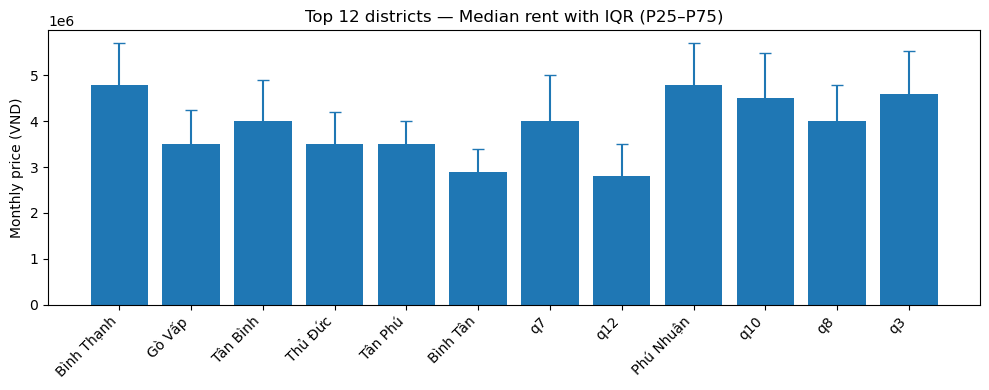

In [6]:
# Plot: Top 12 districts — median price with IQR
top12 = district_summary.head(12).copy()
x = np.arange(len(top12))

plt.figure(figsize=(10,4))
plt.bar(x, top12["price_median"])
lower = top12["price_median"] - top12["price_p25"]
upper = top12["price_p75"] - top12["price_median"]
plt.errorbar(x, top12["price_median"], yerr=[lower, upper], fmt='none', capsize=4)

plt.xticks(x, top12["district_std"].astype(str), rotation=45, ha="right")
plt.ylabel("Monthly price (VND)")
plt.title("Top 12 districts — Median rent with IQR (P25–P75)")
plt.tight_layout()
plt.show()

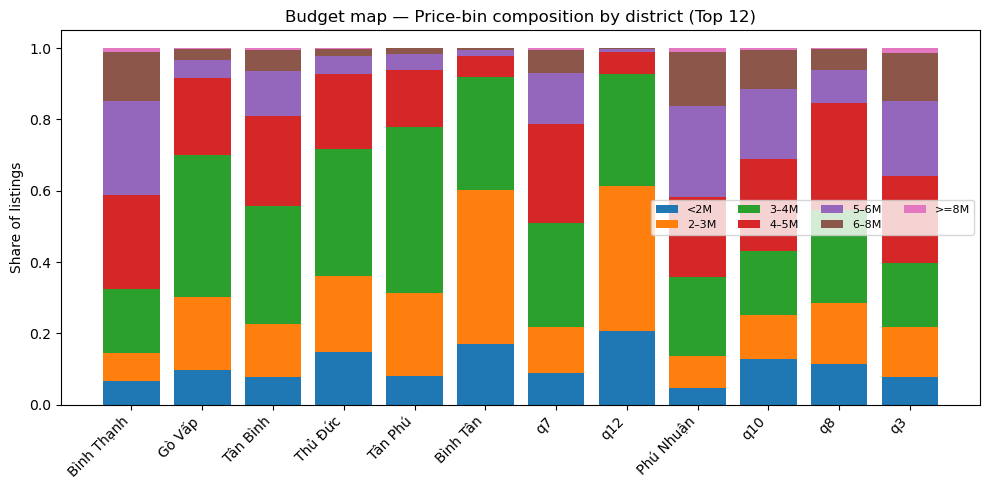

price_bin,<2M,2–3M,3–4M,4–5M,5–6M,6–8M,>=8M
district_std,,,,,,,
Bình Thạnh,0.067089,0.078183,0.179873,0.262282,0.263074,0.137876,0.011622
Gò Vấp,0.098322,0.204592,0.397998,0.216662,0.050339,0.029143,0.002944
Tân Bình,0.076626,0.150354,0.329041,0.254024,0.124598,0.059884,0.005473
Thủ Đức,0.148668,0.212383,0.355652,0.209503,0.052196,0.019078,0.002520
Tân Phú,0.081274,0.231672,0.465438,0.161709,0.042731,0.016339,0.000838
Bình Tân,0.170094,0.431907,0.316287,0.060589,0.015564,0.005003,0.000556
q7,0.088631,0.128362,0.291565,0.278729,0.143643,0.062958,0.006112
q12,0.206023,0.406571,0.315537,0.060917,0.008898,0.001369,0.000684
Phú Nhuận,0.046423,0.089041,0.221461,0.225266,0.254947,0.150685,0.012177


In [7]:
# Plot: Budget map — price bins composition (Top 12)
bins = [-np.inf, 2e6, 3e6, 4e6, 5e6, 6e6, 8e6, np.inf]
labels = ["<2M","2–3M","3–4M","4–5M","5–6M","6–8M",">=8M"]

sub = work[work["district_std"].isin(top12["district_std"])].copy()
sub["price_bin"] = pd.cut(sub["price"], bins=bins, labels=labels)

share = pd.crosstab(sub["district_std"], sub["price_bin"], normalize="index").reindex(top12["district_std"].tolist())

plt.figure(figsize=(10,5))
bottom = np.zeros(len(share))
x = np.arange(len(share.index))

for col in share.columns:
    vals = share[col].fillna(0).values
    plt.bar(x, vals, bottom=bottom, label=str(col))
    bottom += vals

plt.xticks(x, share.index.astype(str), rotation=45, ha="right")
plt.ylabel("Share of listings")
plt.title("Budget map — Price-bin composition by district (Top 12)")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

share

#### B3) “Vùng trũng giá trị” & “Overpriced” theo district (dựa trên CEI)

Chỉ xét district có **>= 300 listings** để giảm nhiễu do mẫu nhỏ.


In [8]:
district_cei = (
    work.groupby("district_std")
    .agg(
        n=("CEI","size"),
        cei_median=("CEI","median"),
        price_median=("price","median"),
        ppsm_median=("price_per_sqm","median"),
        area_median=("area","median"),
        amen_mean=("amenity_score","mean"),
        sec_mean=("security_score","mean"),
        loc_mean=("location_score","mean"),
    )
    .reset_index()
)

district_cei_big = district_cei[district_cei["n"]>=300].copy()

value_zones = district_cei_big.sort_values("cei_median", ascending=False).head(10)
overpriced_zones = district_cei_big.sort_values("cei_median", ascending=True).head(10)

value_zones, overpriced_zones

(   district_std     n  cei_median  price_median    ppsm_median  area_median  \
 23           q9   443    5.813903     3000000.0  123333.333333         25.0   
 15          q12  1461    4.802391     2800000.0  116666.666667         25.0   
 2      Bình Tân  1799    4.731599     2900000.0  116666.666667         25.0   
 11      Tân Phú  2387    4.201019     3500000.0  133333.333333         26.0   
 9       Thủ Đức  2778    3.717931     3500000.0  135000.000000         25.0   
 20           q6   436    3.245230     3500000.0  133333.333333         25.0   
 4        Gò Vấp  3397    3.221704     3500000.0  142307.692308         25.0   
 14          q11   340    3.056794     3800000.0  152000.000000         25.0   
 19           q5   470    3.024983     4000000.0  166666.666667         25.0   
 18           q4   317    3.002327     4000000.0  175000.000000         25.0   
 
     amen_mean  sec_mean  loc_mean  
 23   4.042889  1.532731  0.878104  
 15   3.164271  1.178645  0.569473  
 2    2

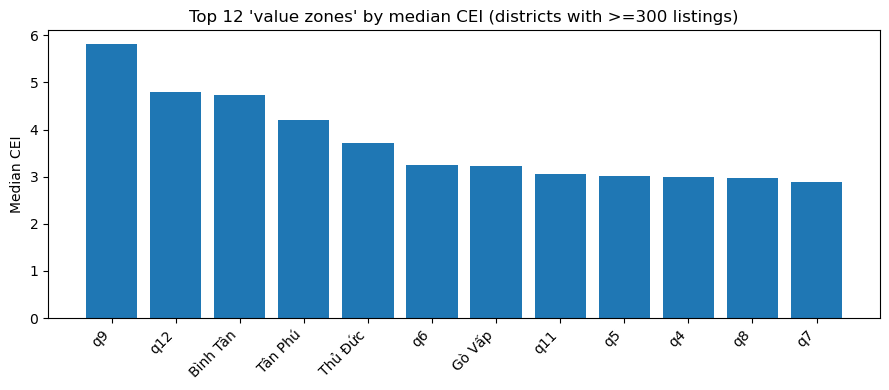

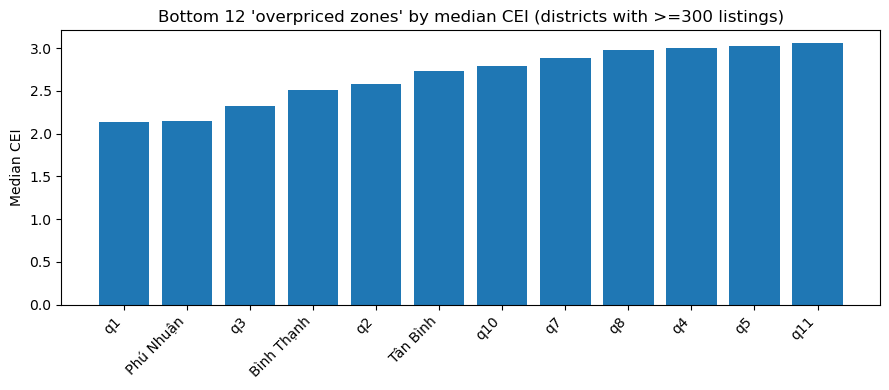

In [9]:
# Plot: CEI median by district (>=300 listings) — top 12 value & bottom 12 overpriced
tmp = district_cei_big.sort_values("cei_median", ascending=False)
top = tmp.head(12)
bot = tmp.tail(12).sort_values("cei_median", ascending=True)

plt.figure(figsize=(9,4))
plt.bar(top["district_std"].astype(str), top["cei_median"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Median CEI")
plt.title("Top 12 'value zones' by median CEI (districts with >=300 listings)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.bar(bot["district_std"].astype(str), bot["cei_median"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Median CEI")
plt.title("Bottom 12 'overpriced zones' by median CEI (districts with >=300 listings)")
plt.tight_layout()
plt.show()

#### B4) Ward-level (chỉ ward có tên chữ, đủ mẫu)

Ward trong data có lẫn mã số; để báo cáo dễ đọc, ta chỉ lấy ward **không phải số** và có `n>=80`.


In [10]:
work["ward_is_numeric"] = work["ward_str"].str.fullmatch(r"\d+").fillna(False)
ward_readable = work[~work["ward_is_numeric"]].copy()

ward_cei = (
    ward_readable.groupby(["district_std","ward_str"])
    .agg(
        n=("CEI","size"),
        cei_median=("CEI","median"),
        price_median=("price","median"),
        ppsm_median=("price_per_sqm","median"),
        area_median=("area","median"),
        amen_mean=("amenity_score","mean"),
        sec_mean=("security_score","mean"),
        loc_mean=("location_score","mean"),
    )
    .reset_index()
)

ward_cei_big = ward_cei[(ward_cei["n"]>=80) & (ward_cei["ward_str"].str.lower()!="nan")].copy()

top_value_wards = ward_cei_big.sort_values("cei_median", ascending=False).head(12)
top_overpriced_wards = ward_cei_big.sort_values("cei_median", ascending=True).head(12)

top_value_wards, top_overpriced_wards

(    district_std         ward_str    n  cei_median  price_median  \
 34      Bình Tân          tân tạo  112    6.913715     2200000.0   
 149          q12   tân chánh hiệp  199    6.207801     2800000.0   
 143          q12       hiệp thành  112    5.341238     2500000.0   
 83       Thủ Đức        linh xuân  141    5.323545     2700000.0   
 30      Bình Tân  bình trị đông b  231    5.192662     3000000.0   
 119      Tân Phú           sơn kỳ  232    5.098269     3200000.0   
 148          q12     trung mỹ tây  140    5.068097     3000000.0   
 145          q12        thạnh lộc  181    4.999631     3000000.0   
 21      Bình Tân           an lạc  142    4.882589     2500000.0   
 146          q12       thạnh xuân  142    4.836892     2600000.0   
 25      Bình Tân        bình hưng  542    4.674855     2900000.0   
 125      Tân Phú        tây thạnh  365    4.666651     3300000.0   
 
        ppsm_median  area_median  amen_mean  sec_mean  loc_mean  
 34   100000.000000         20.0   

## C. KẾT LUẬN
### 1) Nhận xét tổng quan theo district (market snapshot)
- Thị trường tập trung listing nhiều ở **Bình Thạnh, Gò Vấp, Tân Bình, Thủ Đức, Tân Phú, Bình Tân, Q7, Q12** (thể hiện ở bảng `n`).
- Giá thuê và giá/m² có **chênh lệch đáng kể** giữa district; vì vậy nên nhìn đồng thời **giá** và **giá/m²** thay vì chỉ một chỉ số.
- District có **IQR/median** cao là nơi “loạn giá” hơn: cơ hội săn deal tồn tại nhưng cần lọc kỹ điều kiện.

### 2) 'Vùng trũng giá trị' theo district (CEI cao)
- **q9**: CEI~5.81, giá~3.000.000đ, m²~123333đ, area~25m²
- **q12**: CEI~4.80, giá~2.800.000đ, m²~116667đ, area~25m²
- **Bình Tân**: CEI~4.73, giá~2.900.000đ, m²~116667đ, area~25m²
- **Tân Phú**: CEI~4.20, giá~3.500.000đ, m²~133333đ, area~26m²
- **Thủ Đức**: CEI~3.72, giá~3.500.000đ, m²~135000đ, area~25m²
- **q6**: CEI~3.25, giá~3.500.000đ, m²~133333đ, area~25m²
- **Gò Vấp**: CEI~3.22, giá~3.500.000đ, m²~142308đ, area~25m²
- **q11**: CEI~3.06, giá~3.800.000đ, m²~152000đ, area~25m²

**Diễn giải:** Đây là nhóm district mà dữ liệu cho thấy người thuê nhận được **lợi ích tổng hợp** (diện tích + tiện nghi + an ninh + vị trí) tương đối tốt so với chi phí.

### 3) Khu vực có dấu hiệu 'overpriced' theo district (CEI thấp)
- **q1**: CEI~2.14, giá~5.200.000đ, m²~195000đ, area~28m²
- **Phú Nhuận**: CEI~2.15, giá~4.800.000đ, m²~173913đ, area~27m²
- **q3**: CEI~2.33, giá~4.600.000đ, m²~183333đ, area~25m²
- **Bình Thạnh**: CEI~2.51, giá~4.800.000đ, m²~171429đ, area~30m²
- **q2**: CEI~2.58, giá~4.200.000đ, m²~156667đ, area~28m²
- **Tân Bình**: CEI~2.74, giá~4.000.000đ, m²~150715đ, area~25m²
- **q10**: CEI~2.79, giá~4.500.000đ, m²~177778đ, area~25m²
- **q7**: CEI~2.89, giá~4.000.000đ, m²~157143đ, area~25m²

**Diễn giải:** Nhóm này có chi phí tương đối cao so với lợi ích tổng hợp — thường đi kèm **giá/m² cao** hoặc mức giá cao dù lợi ích không tăng tương xứng.

### 4) Ward-level (đọc được) — Top 'value wards' & 'overpriced wards'
**Value wards (CEI cao, n>=80, ward có tên chữ):**
- **Bình Tân / tân tạo** (n=112): CEI~6.91, giá~2.200.000đ, m²~100000đ
- **q12 / tân chánh hiệp** (n=199): CEI~6.21, giá~2.800.000đ, m²~110000đ
- **q12 / hiệp thành** (n=112): CEI~5.34, giá~2.500.000đ, m²~106905đ
- **Thủ Đức / linh xuân** (n=141): CEI~5.32, giá~2.700.000đ, m²~110000đ
- **Bình Tân / bình trị đông b** (n=231): CEI~5.19, giá~3.000.000đ, m²~114286đ
- **Tân Phú / sơn kỳ** (n=232): CEI~5.10, giá~3.200.000đ, m²~122778đ
- **q12 / trung mỹ tây** (n=140): CEI~5.07, giá~3.000.000đ, m²~113333đ
- **Gò Vấp / nan** (n=141): CEI~5.06, giá~3.200.000đ, m²~140000đ
- **q12 / thạnh lộc** (n=181): CEI~5.00, giá~3.000.000đ, m²~122857đ
- **Bình Tân / an lạc** (n=142): CEI~4.88, giá~2.500.000đ, m²~112667đ

**Overpriced wards (CEI thấp, n>=80, ward có tên chữ):**
- **q1 / tân định** (n=129): CEI~1.98, giá~5.500.000đ, m²~200000đ
- **q1 /  nguyễn cư trinh** (n=127): CEI~1.98, giá~5.100.000đ, m²~187500đ
- **q3 / võ thị sáu** (n=143): CEI~2.12, giá~5.300.000đ, m²~190000đ
- **q2 / cát lái** (n=103): CEI~2.12, giá~3.800.000đ, m²~150000đ
- **q1 / đa kao** (n=149): CEI~2.19, giá~5.500.000đ, m²~190625đ
- **Thủ Đức / thạnh mỹ lợi** (n=112): CEI~2.44, giá~4.500.000đ, m²~162731đ
- **Bình Thạnh / nan** (n=178): CEI~2.45, giá~5.000.000đ, m²~175000đ
- **Phú Nhuận / nan** (n=86): CEI~2.51, giá~4.650.000đ, m²~180000đ
- **q7 / tân hưng** (n=178): CEI~2.61, giá~4.200.000đ, m²~166667đ
- **q7 / tân thuận đông** (n=116): CEI~2.63, giá~3.925.000đ, m²~150000đ

### 5) Cảnh báo outlier (top 1% theo giá/m²)
- Dùng ngưỡng **P99 của `price_per_sqm`** để nhận diện nhóm listing **đắt bất thường theo m²**.
- Nếu gặp listing thuộc nhóm này, người thuê nên kiểm tra: loại hình (studio cao cấp?), vị trí thật, chất lượng nội thất, và điều kiện hợp đồng.


## Kết luận
1) **Không nên chọn chỗ ở chỉ vì “giá rẻ”** — hãy chọn theo **đáng tiền** (CEI) để cân bằng diện tích + tiện nghi + an ninh + vị trí.  
2) **Value zones** (CEI cao) là ứng viên tốt để ưu tiên tìm kiếm trước khi mở rộng sang các district đắt hơn.  
3) **Overpriced zones** (CEI thấp) không nhất thiết “xấu”, nhưng người thuê cần **chọn lọc kỹ** hoặc thương lượng để giá phản ánh đúng lợi ích.  
4) Với ward-level, dữ liệu hiện có **trộn ward dạng số**; nếu có mapping chuẩn ward (tên đầy đủ), phân tích ward sẽ còn mạnh hơn.
